#Lab 2: Sydney Golden

#1. State the question

What location factors have the greatest influence on increasing salary in USD for data science positions?

#2. Identify the response and relevant predictors
Salary in USD is the response variable, while the relavent predictor variables include remote ratio, company location, and employee residence.

#3. Related data preparation

In terms of data preparation, we'll need to create a train and test split of the categorical variables. Since all of our response variables are categorical, we will need to apply One Hot Encoding.

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv')

In [3]:
df.head()

,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [4]:
# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_cols = ['remote_ratio', 'company_location', 'employee_residence']
encoded_col = pd.DataFrame(encoder.fit_transform(df[categorical_cols]).toarray())
encoded_col.columns = encoder.get_feature_names_out(categorical_cols)

In [5]:
# Split the Data between test and train
X_train, X_test, y_train, y_test =  train_test_split(encoded_col,
                                                 df['salary_in_usd'],
                                                 train_size = 0.5, test_size = 0.5,
                                                 random_state = 1)

#4. Apply the bagging, random forest, and boosting approach learned in class

Bagging

In [6]:
# fit Bagging model
df_bagging = RandomForestRegressor(max_features=X_train.shape[1],random_state = 1)
df_bagging.fit(X_train,y_train)

print("Number of trees:", df_bagging.n_estimators)
print("Number of features tried at each split:",df_bagging.max_features)
print("Training score: {:.2f}%".format(df_bagging.score(X_train,y_train)*100))

Number of trees: 100
Number of features tried at each split: 153
Training score: 39.33%


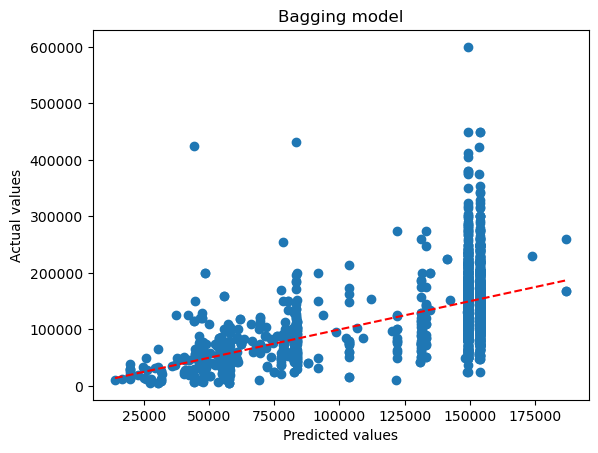

In [7]:
# Predict values
y_pred_bag = df_bagging.predict(X_test)

# plot predicted vs actual values
plt.scatter(y_pred_bag, y_test)
plt.plot([min(y_pred_bag), max(y_pred_bag)], [min(y_pred_bag), max(y_pred_bag)], 'r--')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Bagging model');

In [8]:
# fit Random Forests model
df_bagging = RandomForestRegressor(max_features=X_train.shape[1]
                                       ,random_state = 1
                                       ,n_estimators=25)

df_bagging.fit(X_train,y_train)

# Predict values
y_pred_bag = df_bagging.predict(X_test)

# find the MSE
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_bag)))

Mean Squared Error: 3432409315.59


Random Forest

In [9]:
# fit Random Forests model
df_rf = RandomForestRegressor(max_features=3 #limit to the 3 predictors
                                       ,random_state = 1)

df_rf.fit(X_train,y_train)

# Predict values
y_pred_rf = df_rf.predict(X_test)

Boosting

In [10]:
# fit Gradient Boosting model
boost_df = GradientBoostingRegressor(n_estimators=5000, max_depth=4
                                         , random_state=1)
boost_df.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",5000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

#5. Learn a new boosting methods and apply it to your question.

Catboost

In [11]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

# Initialize and train CatBoost Regressor
model_catboost = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, random_seed=1, verbose=False)
model_catboost.fit(X_train, y_train)

# Predict on test set
y_pred_catboost = model_catboost.predict(X_test)


#6. Compare the model results (model performance, feature importance, etc.)

Bagging

In [12]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bagging = pd.DataFrame({'Feature': X_train.columns, 'Importance': df_bagging.feature_importances_})
importances_df_bagging = importances_df_bagging.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bagging)

                   Feature  Importance
0    employee_residence_US    0.733660
1    employee_residence_CA    0.070958
2      company_location_IN    0.018657
3    employee_residence_DE    0.018530
4           remote_ratio_0    0.017023
..                     ...         ...
148  employee_residence_MK    0.000000
149  employee_residence_KW    0.000000
150  employee_residence_MA    0.000000
151  employee_residence_MD    0.000000
152  employee_residence_SE    0.000000

[153 rows x 2 columns]


In [13]:
# find the MSE
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_bag)))

Mean Squared Error: 3432409315.59


Random Forest

In [14]:
# create a dataframe of feature importances and their corresponding column names
importances_df_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': df_rf.feature_importances_})
importances_df_rf = importances_df_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_rf)

                   Feature  Importance
0    employee_residence_US    0.213850
1      company_location_US    0.165050
2      company_location_IN    0.063224
3    employee_residence_IN    0.054115
4          remote_ratio_50    0.031497
..                     ...         ...
148  employee_residence_MK    0.000000
149  employee_residence_KW    0.000000
150  employee_residence_MA    0.000000
151  employee_residence_MD    0.000000
152  employee_residence_SE    0.000000

[153 rows x 2 columns]


In [15]:
# find the MSE
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_rf)))

Mean Squared Error: 3397853757.77


Boosting (Gradient)

In [16]:
# create a dataframe of feature importances and their corresponding column names
importances_boost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost_df.feature_importances_})
importances_boost_df = importances_boost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost_df)

                   Feature  Importance
0    employee_residence_US    0.753107
1    employee_residence_CA    0.080673
2      company_location_IN    0.020568
3    employee_residence_DE    0.016105
4           remote_ratio_0    0.013022
..                     ...         ...
148  employee_residence_MK    0.000000
149  employee_residence_KW    0.000000
150  employee_residence_MA    0.000000
151  employee_residence_MD    0.000000
152  employee_residence_SE    0.000000

[153 rows x 2 columns]


In [17]:
# Predict values for Gradient Boosting
y_pred_boost = boost_df.predict(X_test)

# find the MSE
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_boost)))

Mean Squared Error: 3433739604.03


CatBoost

In [18]:
# create a dataframe of feature importances and their corresponding column names
importances_df_catboost = pd.DataFrame({'Feature': X_train.columns, 'Importance': model_catboost.get_feature_importance()})
importances_df_catboost = importances_df_catboost.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_catboost)

                   Feature  Importance
0    employee_residence_US   62.202021
1      company_location_US   19.793276
2    employee_residence_CA    5.379483
3      company_location_CA    3.225632
4      company_location_IN    1.682923
..                     ...         ...
148  employee_residence_LT    0.000000
149  employee_residence_KW    0.000000
150  employee_residence_MK    0.000000
151  employee_residence_SE    0.000000
152  employee_residence_UA    0.000000

[153 rows x 2 columns]


In [19]:
# Evaluate the model
mse_catboost = mean_squared_error(y_test, y_pred_catboost)
print(f"CatBoost Mean Squared Error: {mse_catboost:.2f}")

CatBoost Mean Squared Error: 3419506454.59


In [20]:
model_mse = {
    'Bagging': 2896390389.88,
    'Random Forest': 2892224427.77,
    'Gradient Boosting': 2905355402.60,
    'CatBoost': 2911692706.74
}

mse_comparison_df = pd.DataFrame(model_mse.items(), columns=['Model', 'Mean Squared Error'])
mse_comparison_df = mse_comparison_df.sort_values(by='Mean Squared Error', ascending=True).reset_index(drop=True)

print("Model Comparison - Mean Squared Error:")
print(mse_comparison_df)

Model Comparison - Mean Squared Error:
               Model  Mean Squared Error
0      Random Forest        2.892224e+09
1            Bagging        2.896390e+09
2  Gradient Boosting        2.905355e+09
3           CatBoost        2.911693e+09


#7. Interpret the results

Overall, the models have low predictive ability. In the first bagging model, the training score was only at 39%. A low training score indicates that the three location predictor variables chosen likely had a weak relationship with the response variable. Out of these weaker response variables, employment residency in the United States had the greatest feature importance in every model.

Although all models performed poorly on the testing data, the random forest model had the lowest testing MSE and would be chosen as the best model. In random forest models, only a portion of predictor variables are considered. It's possible that the random forest model's performance was slightly improved due to the amount of predictor variables already being limited before any modeling.